In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
%matplotlib inline

In [2]:
mask=np.array(Image.open("/kaggle/input/wodcloud-twiter-pic/twitter.png"))

In [3]:
df=pd.read_csv("/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv")

In [4]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
df.rename(columns={'Positive': 'category'}, inplace=True)

In [6]:
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)

In [7]:
df.shape

(74681, 4)

In [8]:
df.isnull().sum()

2401             0
Borderlands      0
category         0
text           686
dtype: int64

In [9]:
df["Borderlands"].value_counts()

Borderlands
Microsoft                            2400
MaddenNFL                            2400
TomClancysRainbowSix                 2400
LeagueOfLegends                      2394
CallOfDuty                           2394
Verizon                              2382
CallOfDutyBlackopsColdWar            2376
ApexLegends                          2376
Facebook                             2370
WorldOfCraft                         2364
Dota2                                2364
NBA2K                                2352
TomClancysGhostRecon                 2346
Battlefield                          2346
FIFA                                 2340
Overwatch                            2334
Xbox(Xseries)                        2334
johnson&johnson                      2328
Amazon                               2316
HomeDepot                            2310
PlayStation5(PS5)                    2310
CS-GO                                2304
Cyberpunk2077                        2304
GrandTheftAuto(GTA)   

In [10]:
df["2401"].value_counts()

2401
9200    6
9199    6
2402    6
2403    6
2404    6
       ..
2435    6
2436    6
2437    6
2438    6
2401    5
Name: count, Length: 12447, dtype: int64

In [11]:
df["category"].value_counts()

category
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [12]:
df.head()

,2401,Borderlands,category,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


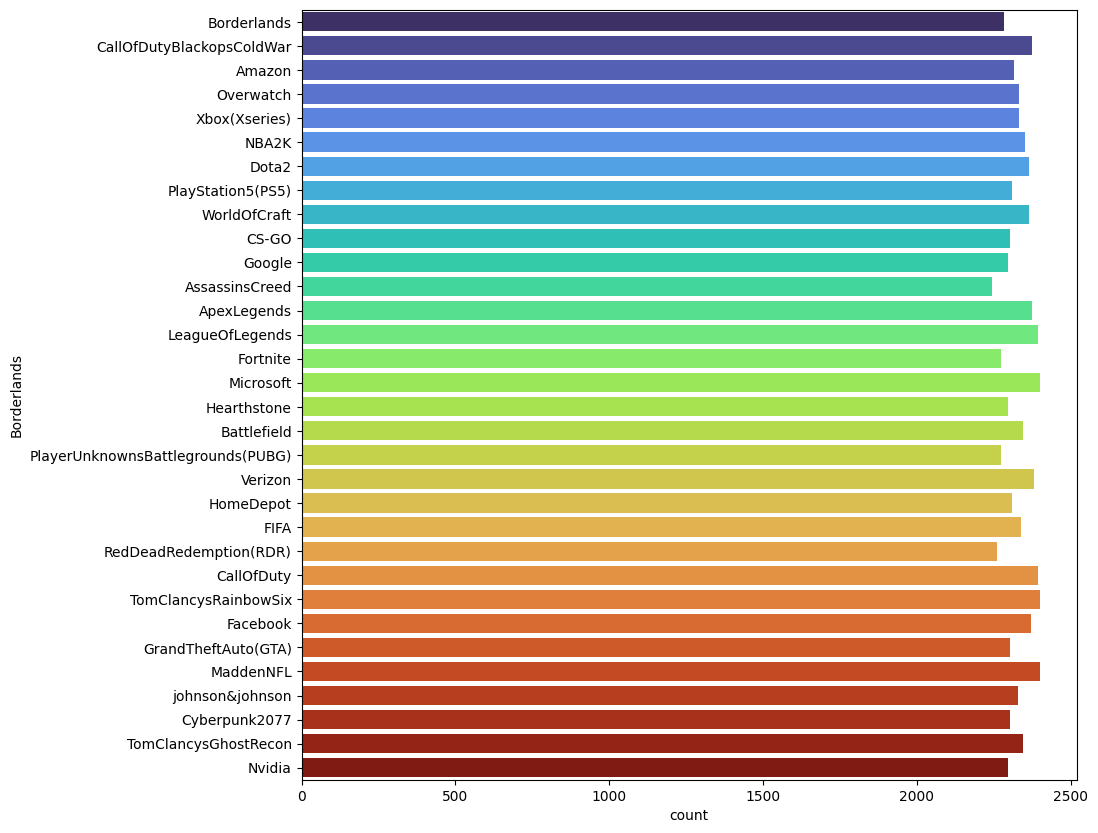

In [13]:
plt.figure(figsize=(10,10))
sns.countplot(y="Borderlands",data=df,palette="turbo")
plt.show()

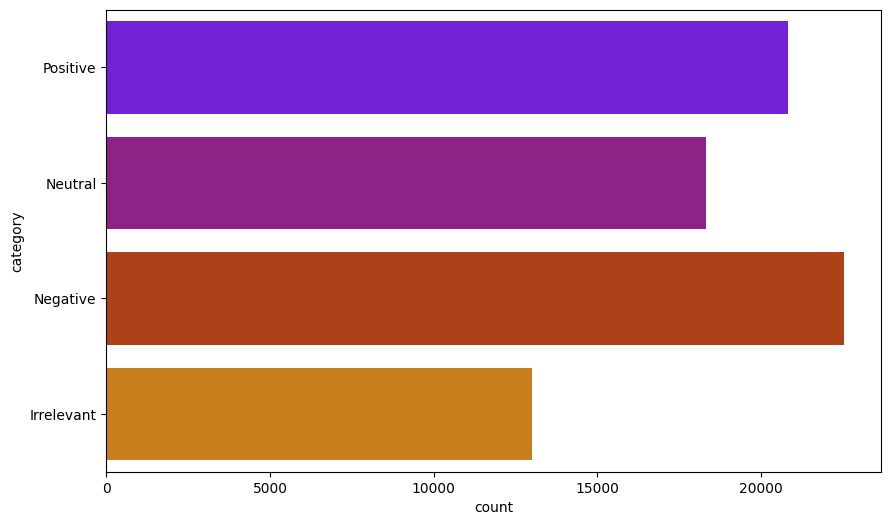

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(y="category",data=df,palette="gnuplot")
plt.show()

In [15]:
df["text"]=df["text"].astype(str)
from wordcloud import WordCloud, STOPWORDS

# Text clean

In [16]:
from bs4 import BeautifulSoup
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
def clean_text(text):
    if isinstance(text, str):
        # Remove HTML tags
        text = BeautifulSoup(text, 'html.parser').get_text()

        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z]", " ", text)

        # Remove punctuation
        text = text.translate(str.maketrans("", "", string.punctuation))

        # Remove emojis
        emoji_pattern = re.compile("["
                                   u"\U0001F600-\U0001F64F"  # emoticons
                                   u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                                   u"\U0001F680-\U0001F6FF"  # transport & map symbols
                                   u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                                   u"\U00002702-\U000027B0"
                                   u"\U000024C2-\U0001F251"
                                   "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        # Convert to lowercase
        text = text.lower()

        # Remove stop words
        stop_words = set(stopwords.words('english'))
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in stop_words]
        text = ' '.join(tokens)

        return text
    else:
        # If the text is not a string (NaN or other), return an empty string
        return ""

In [18]:
df["text"]=df["text"].apply(clean_text)

/tmp/ipykernel_33/1050217019.py:4: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, 'html.parser').get_text()


# all text worcloud

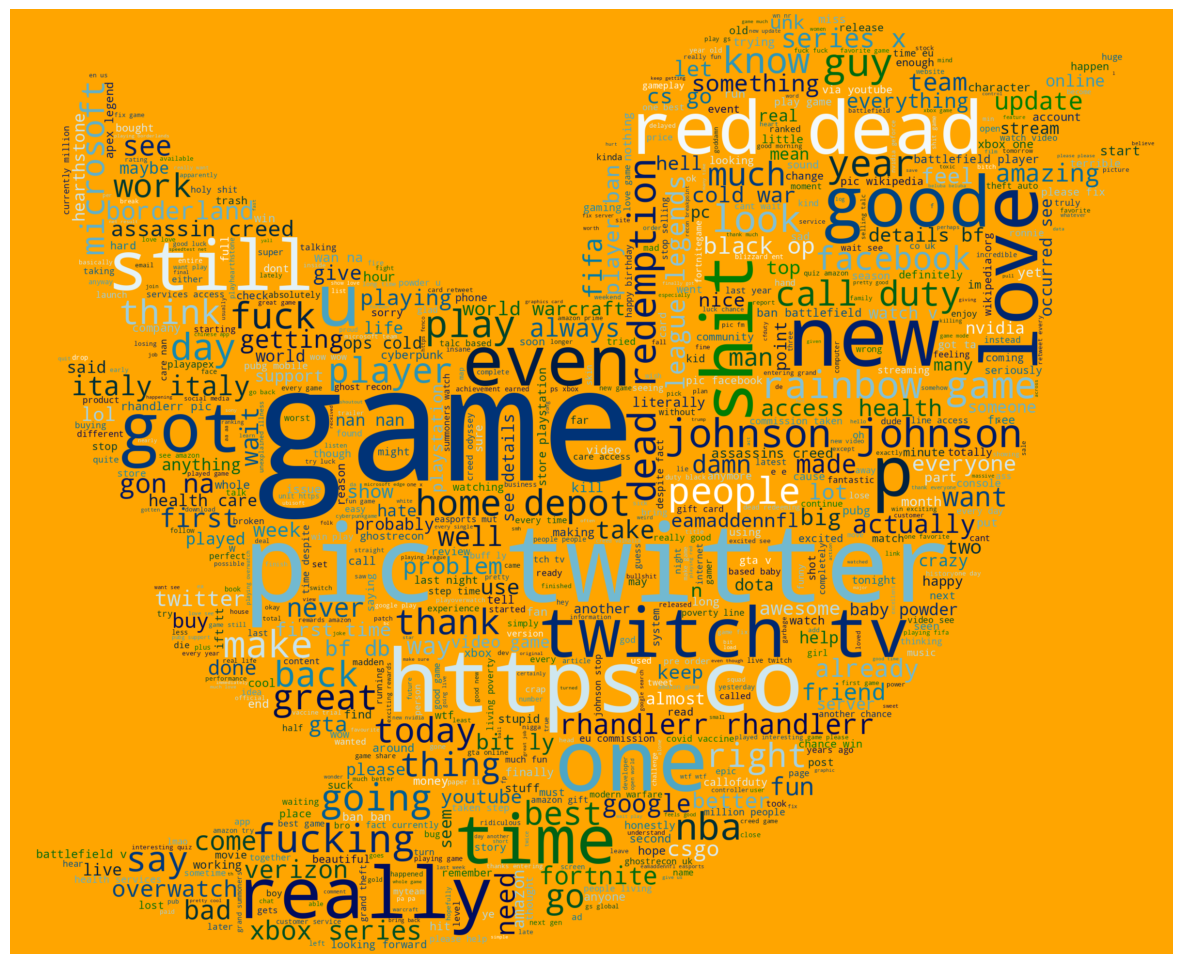

In [19]:
plt.figure(figsize=(15,15))
all_text=" ".join(df['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='orange', max_words=800,colormap="ocean",mask=mask).generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# positive text wordcloud

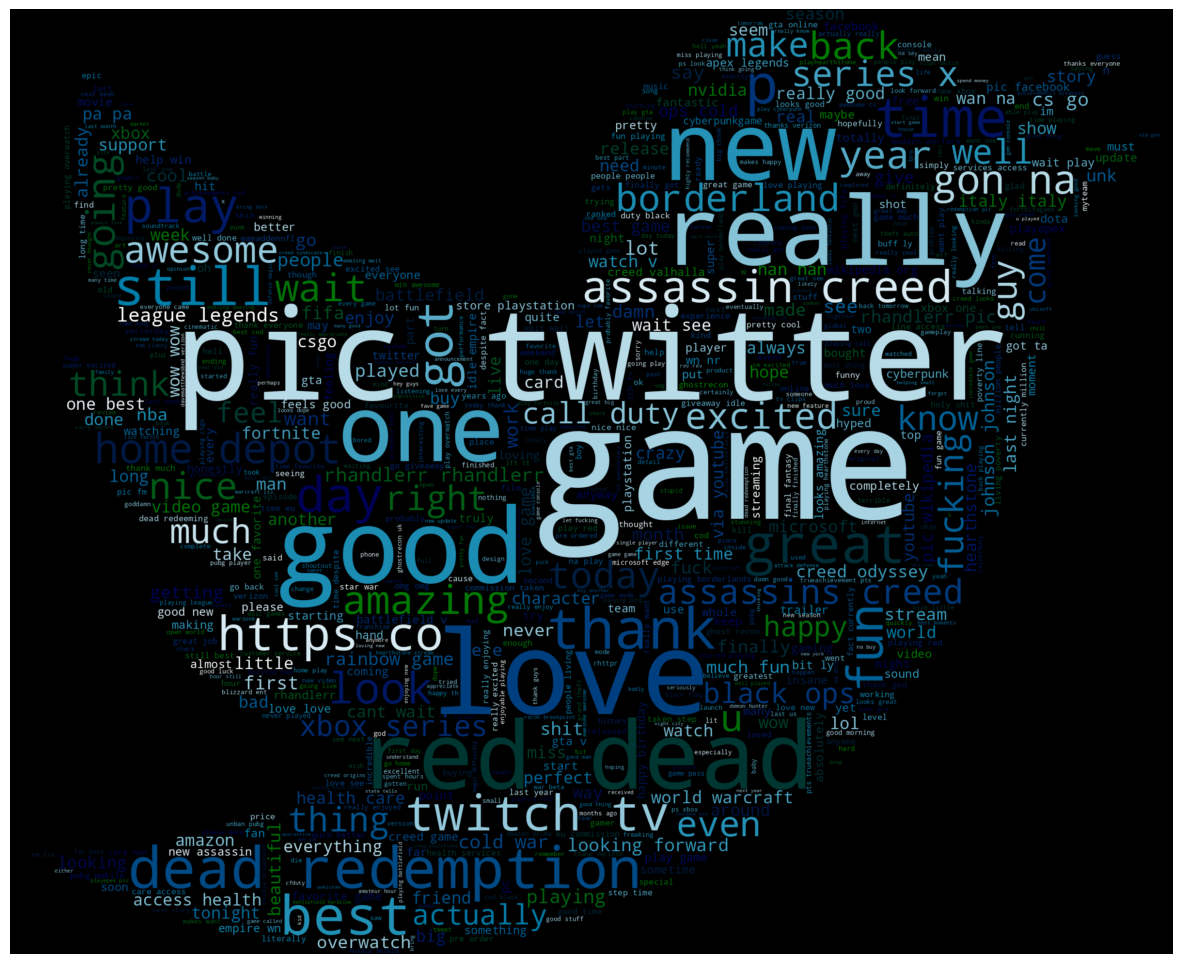

In [20]:
all_text=df[df["category"]=="Positive"]["text"]
plt.figure(figsize=(15,15))
p_text=" ".join(all_text)
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="ocean",mask=mask).generate(p_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Negative text  wordcloud

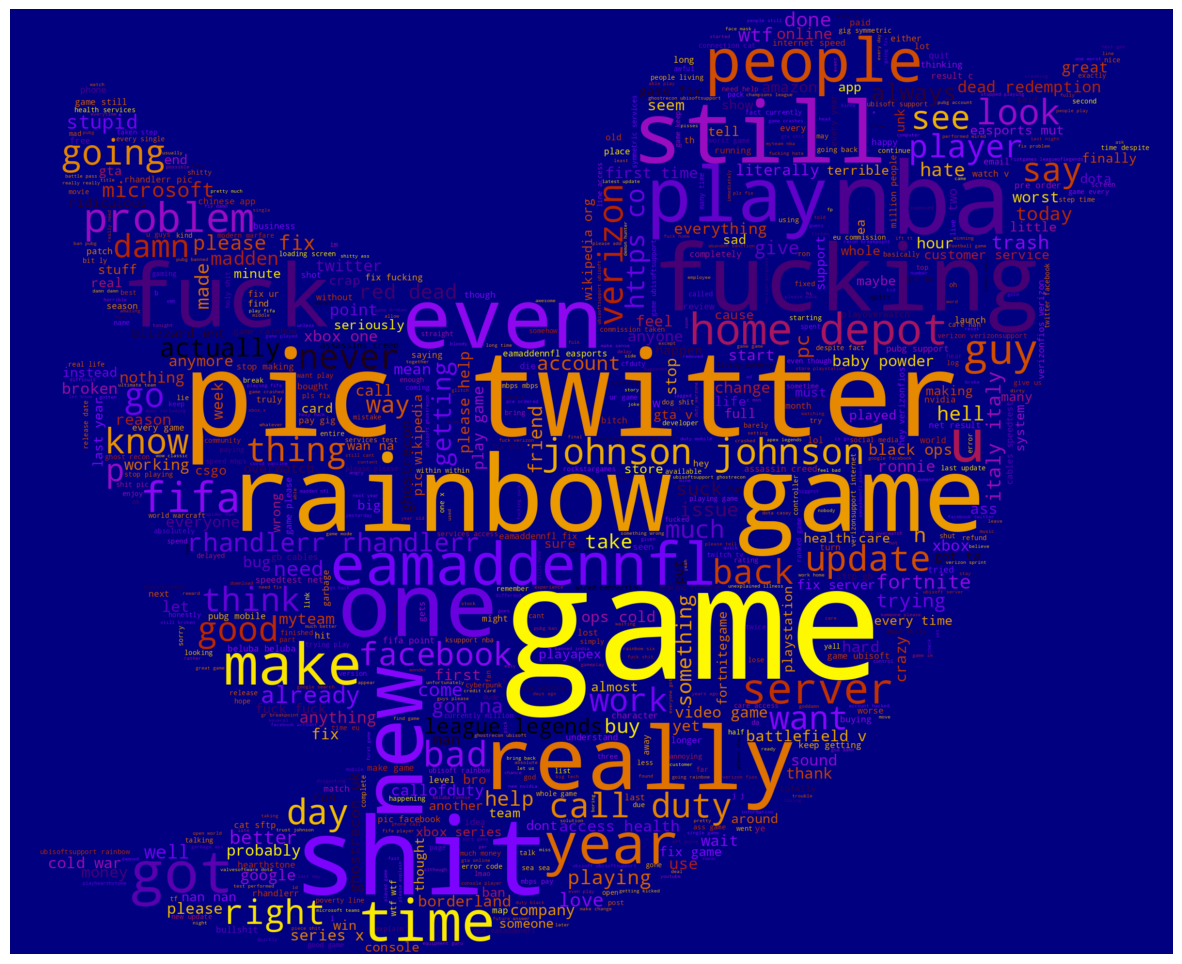

In [21]:
all_text=df[df["category"]=="Negative"]["text"]
plt.figure(figsize=(15,15))
n_text=" ".join(all_text)
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='navy', max_words=800,colormap="gnuplot",mask=mask).generate(n_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Neutral wordcloud

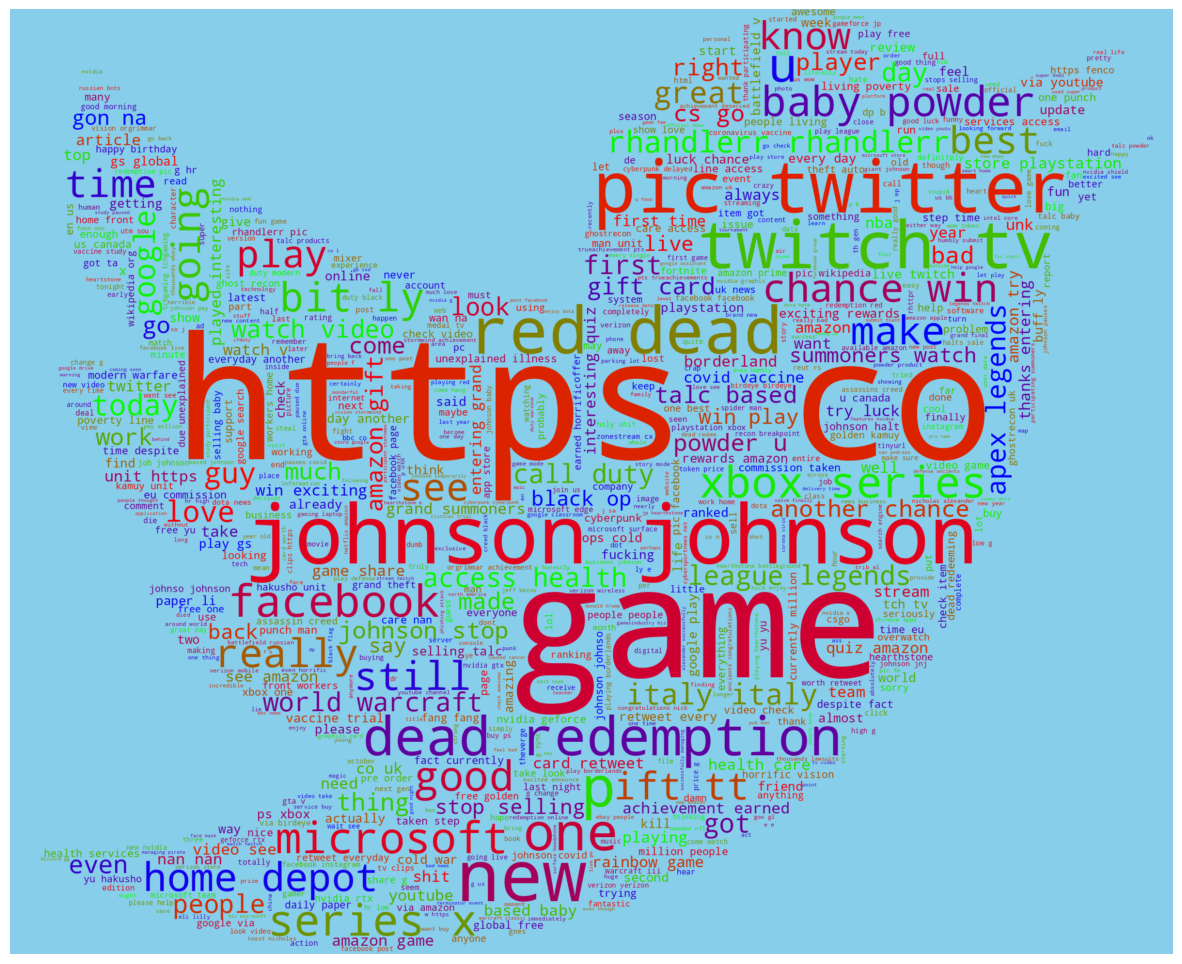

In [39]:
all_text=df[df["category"]=="Neutral"]["text"]
plt.figure(figsize=(15,15))
ne_text=" ".join(all_text)
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='skyblue', max_words=800,colormap="brg",mask=mask).generate(ne_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# irrelevant text wordcloud

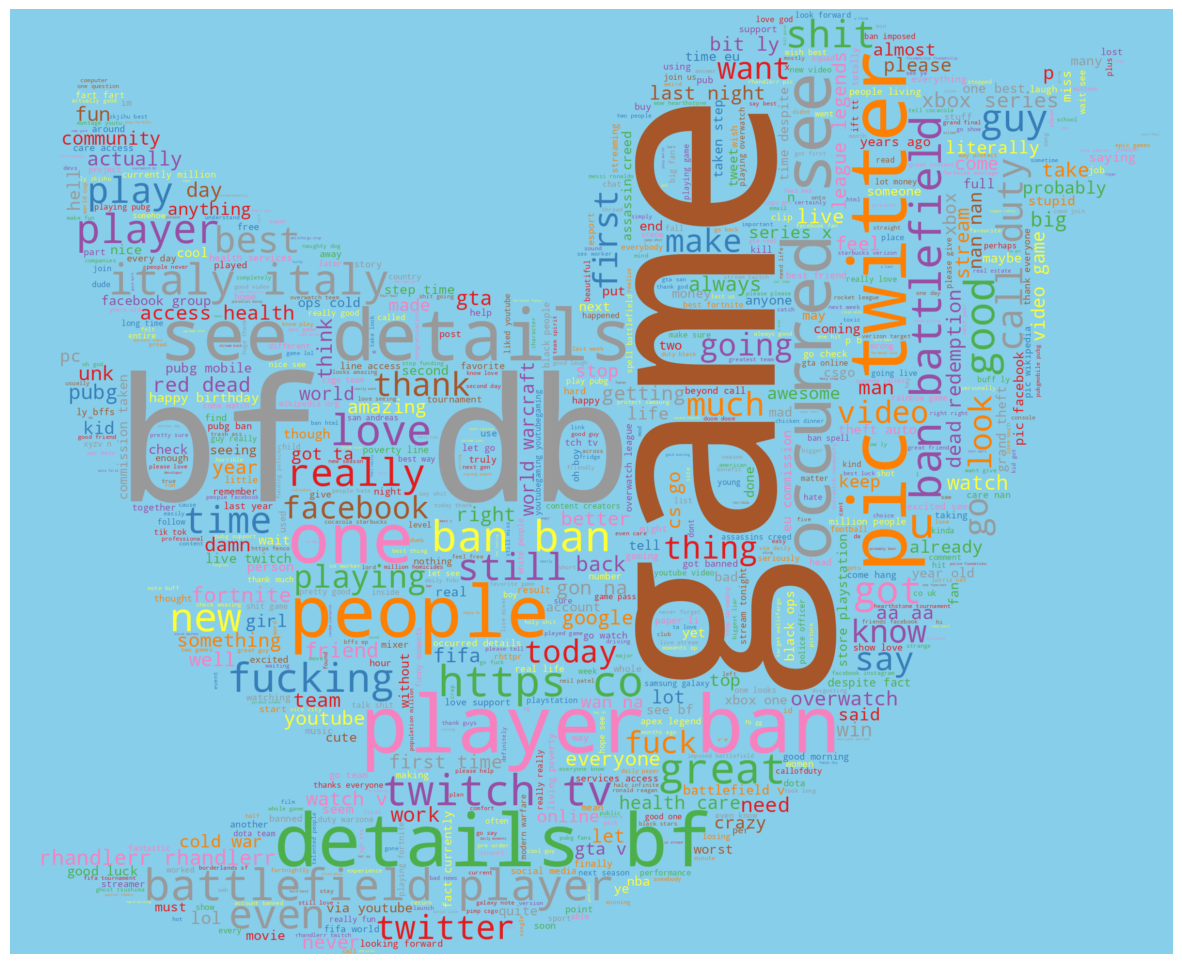

In [23]:
i_text=df[df["category"]=="Irrelevant"]["text"]
plt.figure(figsize=(15,15))
ne_text=" ".join(i_text)
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='skyblue', max_words=800,colormap="Set1",mask=mask).generate(ne_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# compare text length

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

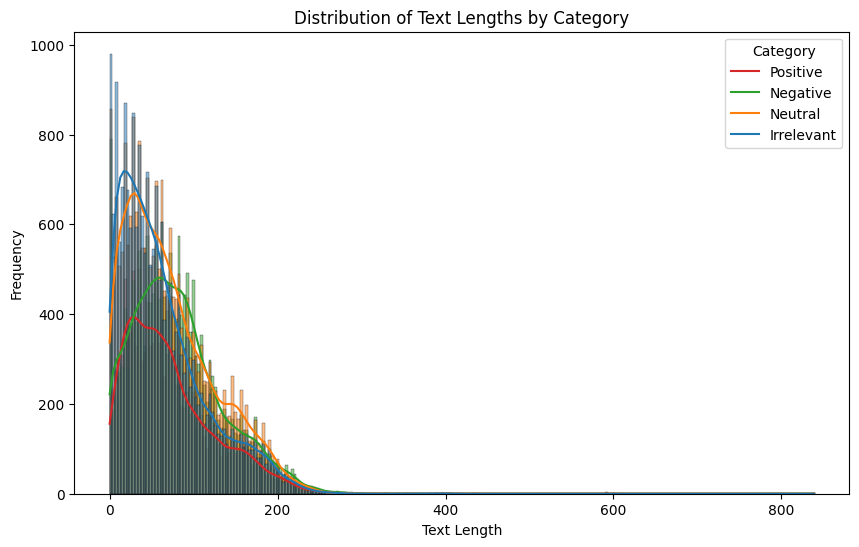

In [24]:
p_len=df[df["category"]=="Positive"]["text"].str.len()
n_len=df[df["category"]=="Negative"]["text"].str.len()
neu_len=df[df["category"]=="Neutral"]["text"].str.len()
irr_len=df[df["category"]=="Irrelevant"]["text"].str.len()
lengths_df = pd.DataFrame({
    "Positive": p_len,
    "Negative": n_len,
    "Neutral": neu_len,
    "Irrelevant": irr_len
})

plt.figure(figsize=(10, 6))
sns.histplot(data=lengths_df, kde=True)
plt.title('Distribution of Text Lengths by Category')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend(title='Category', labels=['Positive', 'Negative', 'Neutral', 'Irrelevant'])
plt.show()

# most common words in positive text

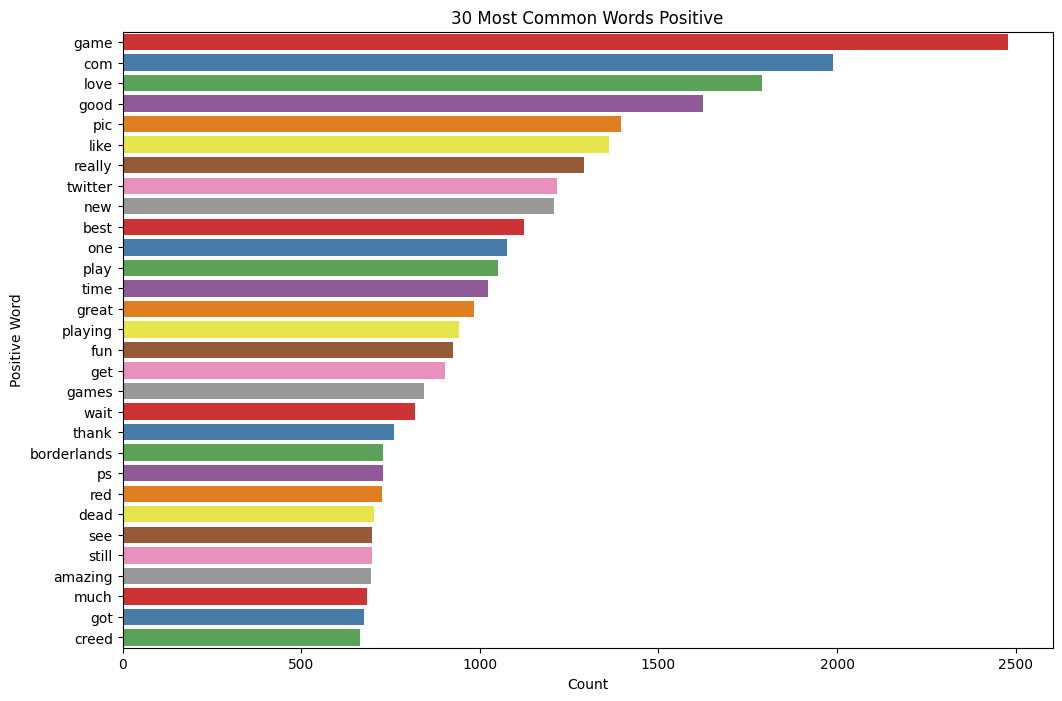

In [25]:
from collections import Counter
pos_text = df[df["category"] == "Positive"]
data_set = pos_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Positive')
plt.xlabel('Count')
plt.ylabel('Positive Word')
plt.show()

# most common words in negative text

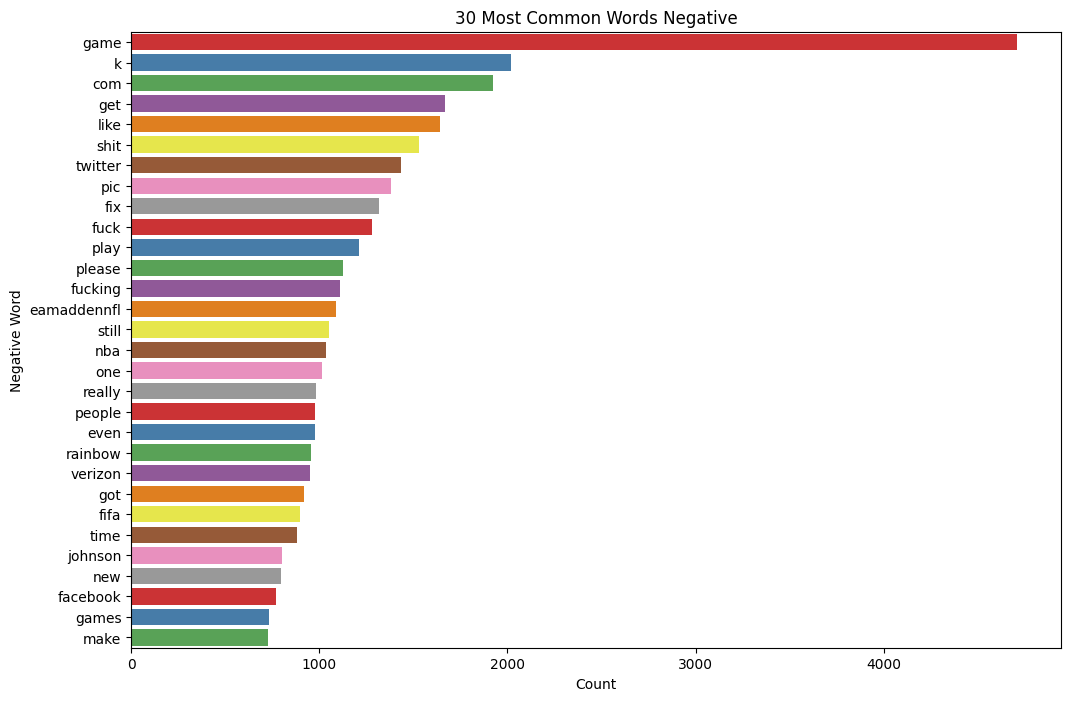

In [26]:

n_text = df[df["category"] == "Negative"]
data_set = n_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Negative')
plt.xlabel('Count')
plt.ylabel('Negative Word')
plt.show()

# Most common words in neutral text

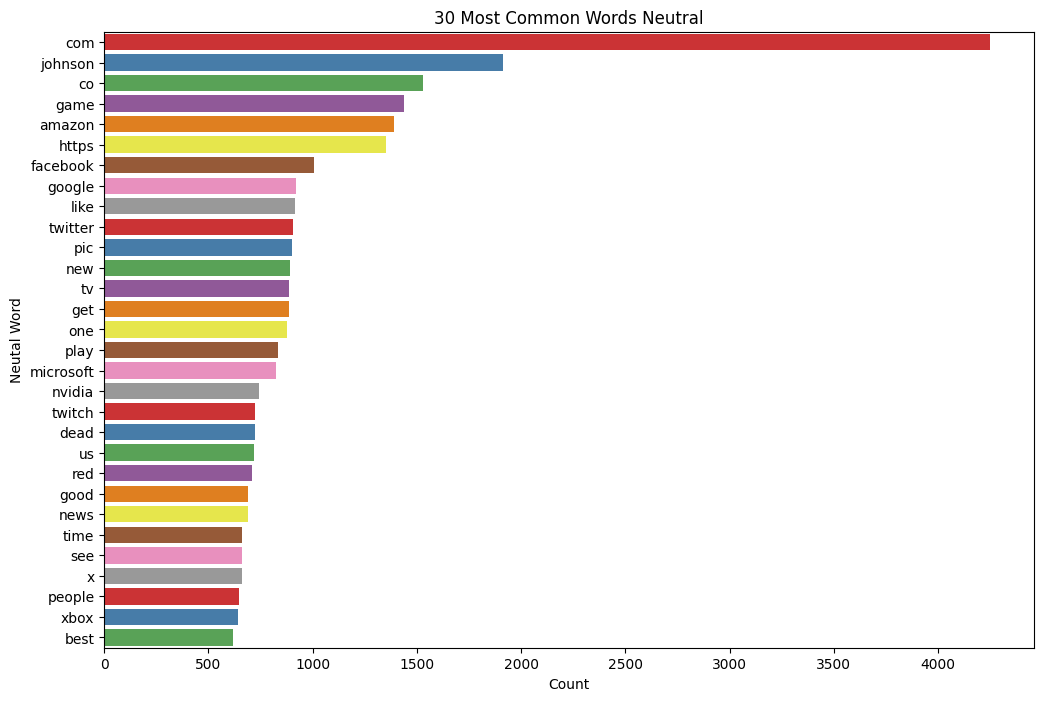

In [27]:

neu_text = df[df["category"] == "Neutral"]
data_set = neu_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Neutral')
plt.xlabel('Count')
plt.ylabel('Neutal Word')
plt.show()

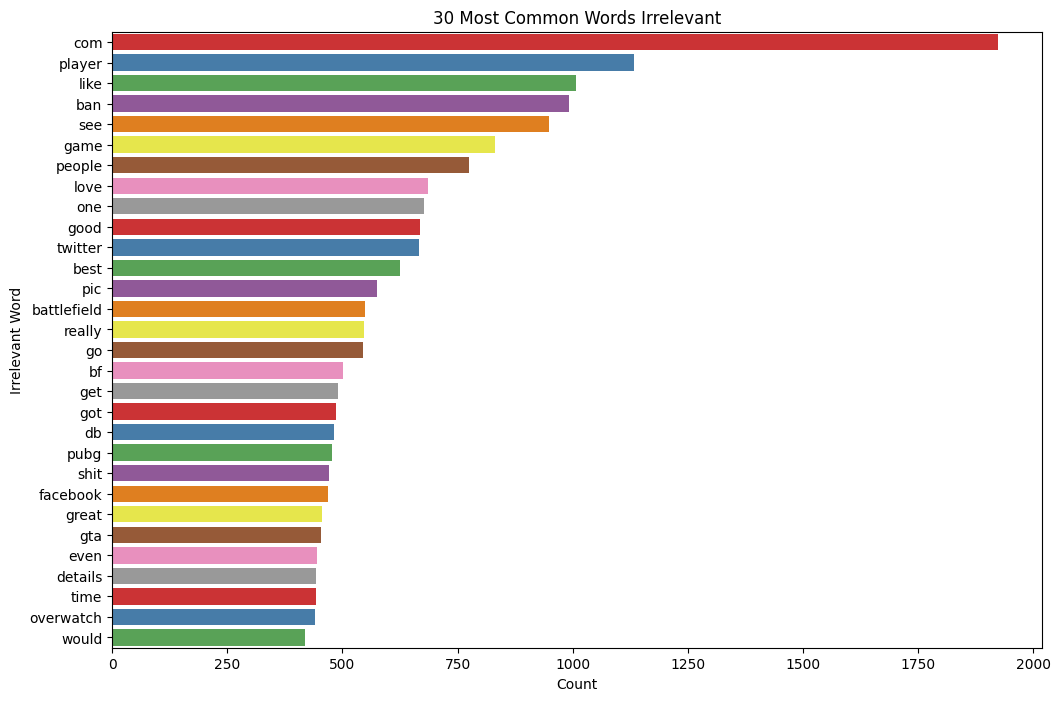

In [28]:

irr_text = df[df["category"] == "Irrelevant"]
data_set = irr_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Irrelevant')
plt.xlabel('Count')
plt.ylabel('Irrelevant Word')
plt.show()

# count character

In [29]:
df["character_count"]=df["text"].str.len()

# count word

In [30]:
df['word_count'] = df['text'].str.split().str.len()

# Count Sentence

In [31]:
df['sentence_count'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [32]:
df.head()

,2401,Borderlands,category,text,character_count,word_count,sentence_count
0,2401,Borderlands,Positive,coming borders kill,19,3,1
1,2401,Borderlands,Positive,im getting borderlands kill,27,4,1
2,2401,Borderlands,Positive,im coming borderlands murder,28,4,1
3,2401,Borderlands,Positive,im getting borderlands murder,29,4,1
4,2401,Borderlands,Positive,im getting borderlands murder,29,4,1


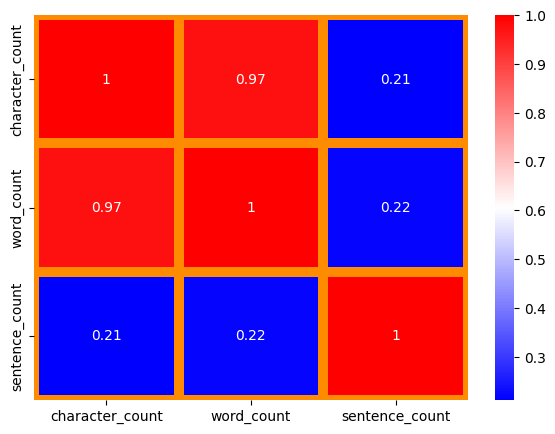

In [33]:
cor=df[["character_count","word_count","sentence_count"]].corr()
plt.figure(figsize=(7,5))
sns.heatmap(cor,annot=True,cmap="bwr",linewidths=7, linecolor='darkorange')
plt.show()

# character count

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

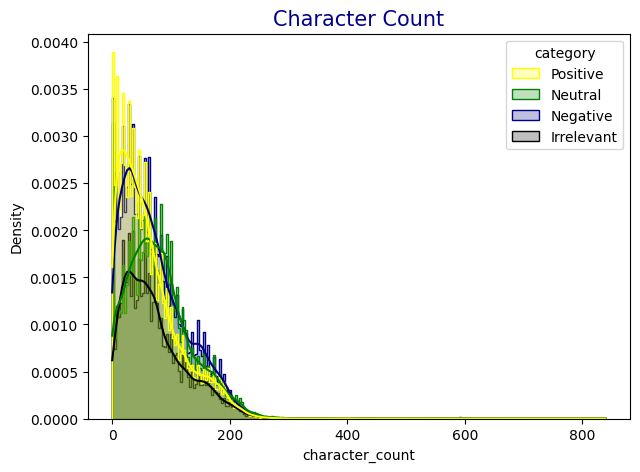

In [34]:
color=["yellow","green","navy","black"]
plt.figure(figsize=(7,5))

sns.histplot(data=df,x="character_count",palette=color,kde=True,hue="category",element="step",stat="density")
plt.title("Character Count",fontsize=15,color="darkblue")
plt.show()

# word count

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

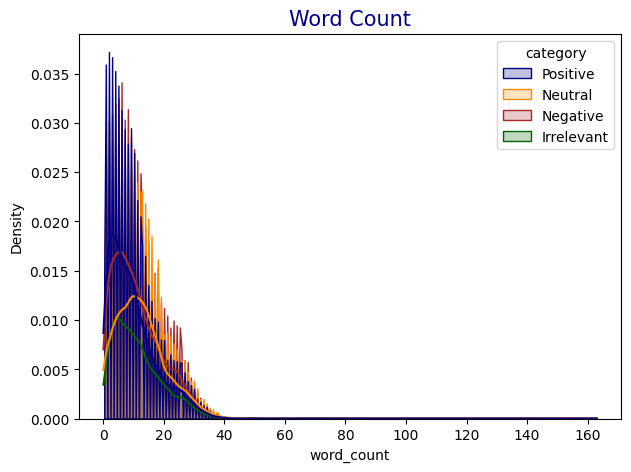

In [35]:
color=["navy","darkorange","brown","darkgreen"]
plt.figure(figsize=(7,5))

sns.histplot(data=df,x="word_count",palette=color,kde=True,hue="category",element="poly",stat="density")
plt.title("Word Count",fontsize=15,color="darkblue")
plt.show()

# Sentence count

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

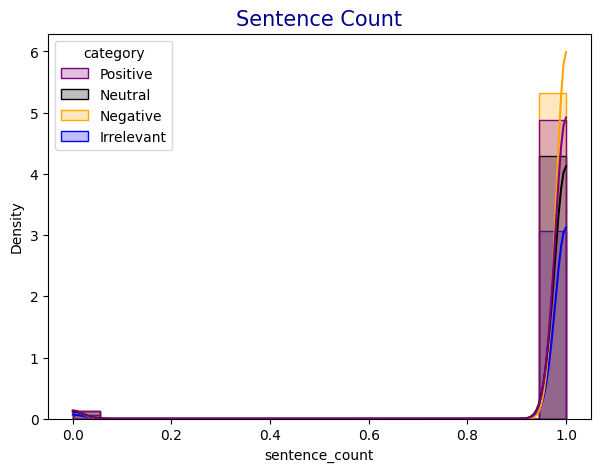

In [36]:
color=["purple","black","orange","blue"]
plt.figure(figsize=(7,5))
sns.histplot(data=df,x="sentence_count",palette=color,kde=True,hue="category",element="step",stat="density")
plt.title("Sentence Count",fontsize=15,color="darkblue")
plt.show()

In [37]:
avg_len=df["text"].apply(len)
avg_len=avg_len.mean()
print(f"Average Text Length is : {avg_len:.2f}")

Average Text Length is : 71.38


In [38]:
max_len=df["text"].apply(len)
max_len.max()

839